In [33]:
%matplotlib inline
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns

In [34]:
target_column = "health_condition"

In [35]:
model_names = ["adaboost", "catboost", "hgbc", "knn", "lasso", "lgbm", "linearsvc", "logistic", "random_forest", "svc_nystroem", "svc_rbf", "xgboost"]
intermediate_files = ["valid_features", "valid_features_oheencoded", "valid_features_oheencoded_imputed", "valid_features_oheencoded_imputed_scaled"]
model_intermediate_indices = [2, 0, 0, 3, 3, 0, 3, 3, 1, 3, 3, 0]

y_valid = pd.read_csv("../data/intermediate/valid_labels.csv")
valid_sample_weight = compute_sample_weight(class_weight="balanced", y=y_valid)

valid_scores = []
for idx, model_name in enumerate(model_names):
    intermediate_file_str = intermediate_files[model_intermediate_indices[idx]]
    model_path = f"../models/{model_name}_80.pkl"
    intermediate_file_path = f"../data/intermediate/{intermediate_file_str}.csv"

    model_base = joblib.load(model_path)
    valid_features = pd.read_csv(intermediate_file_path)

    if model_name in ["catboost", "lgbm", "xgboost"]:
        if model_name == "catboost":
            valid_features['diet_type'] = valid_features['diet_type'].fillna('null')
            valid_features['gender'] = valid_features['gender'].fillna('null')

        valid_features['diet_type'] = valid_features['diet_type'].astype('category')
        valid_features['gender'] = valid_features['gender'].astype('category')

    if model_name == "svc_nystroem":
        nystroem_model = joblib.load("../models/nystroem_80.pkl")
        valid_features = nystroem_model.transform(valid_features)

    if model_name == "svc_rbf":
        rbf_model = joblib.load("../models/rbf_80.pkl")
        valid_features = rbf_model.transform(valid_features)

    y_pred = model_base.predict(valid_features)
    val_score = balanced_accuracy_score(y_valid, y_pred, sample_weight=valid_sample_weight)
    valid_scores.append(val_score)

df_scores = pd.DataFrame({'Estimator': model_names, 'Score': valid_scores})

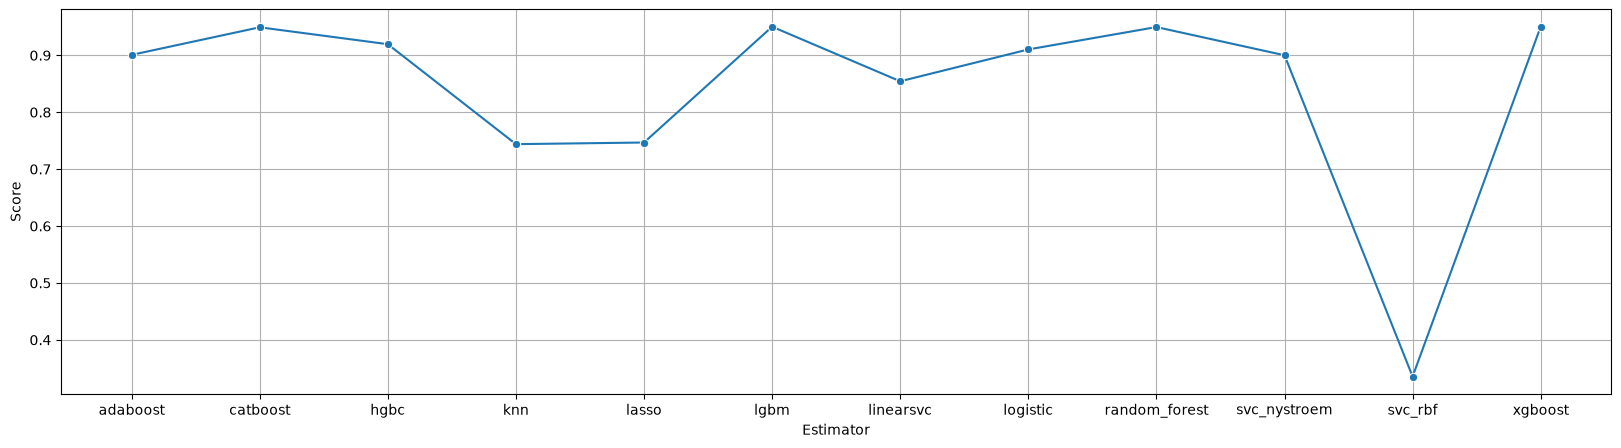

In [37]:
fig,ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data=df_scores, x='Estimator', y='Score', marker='o')
plt.grid()